In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/housing.csv")

In [2]:
# Check values
df.shape
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [3]:
# Clean dataset of na
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [4]:
# Save processed csv
df.to_csv("../data/processed/housing_cleaned.csv", index=False)

## EDA - Skewness Analysis
Distribution plots with mean, median, and ±3σ bounds for each numerical feature.
Right-skewed features have mean > median (red line to the right of green line).

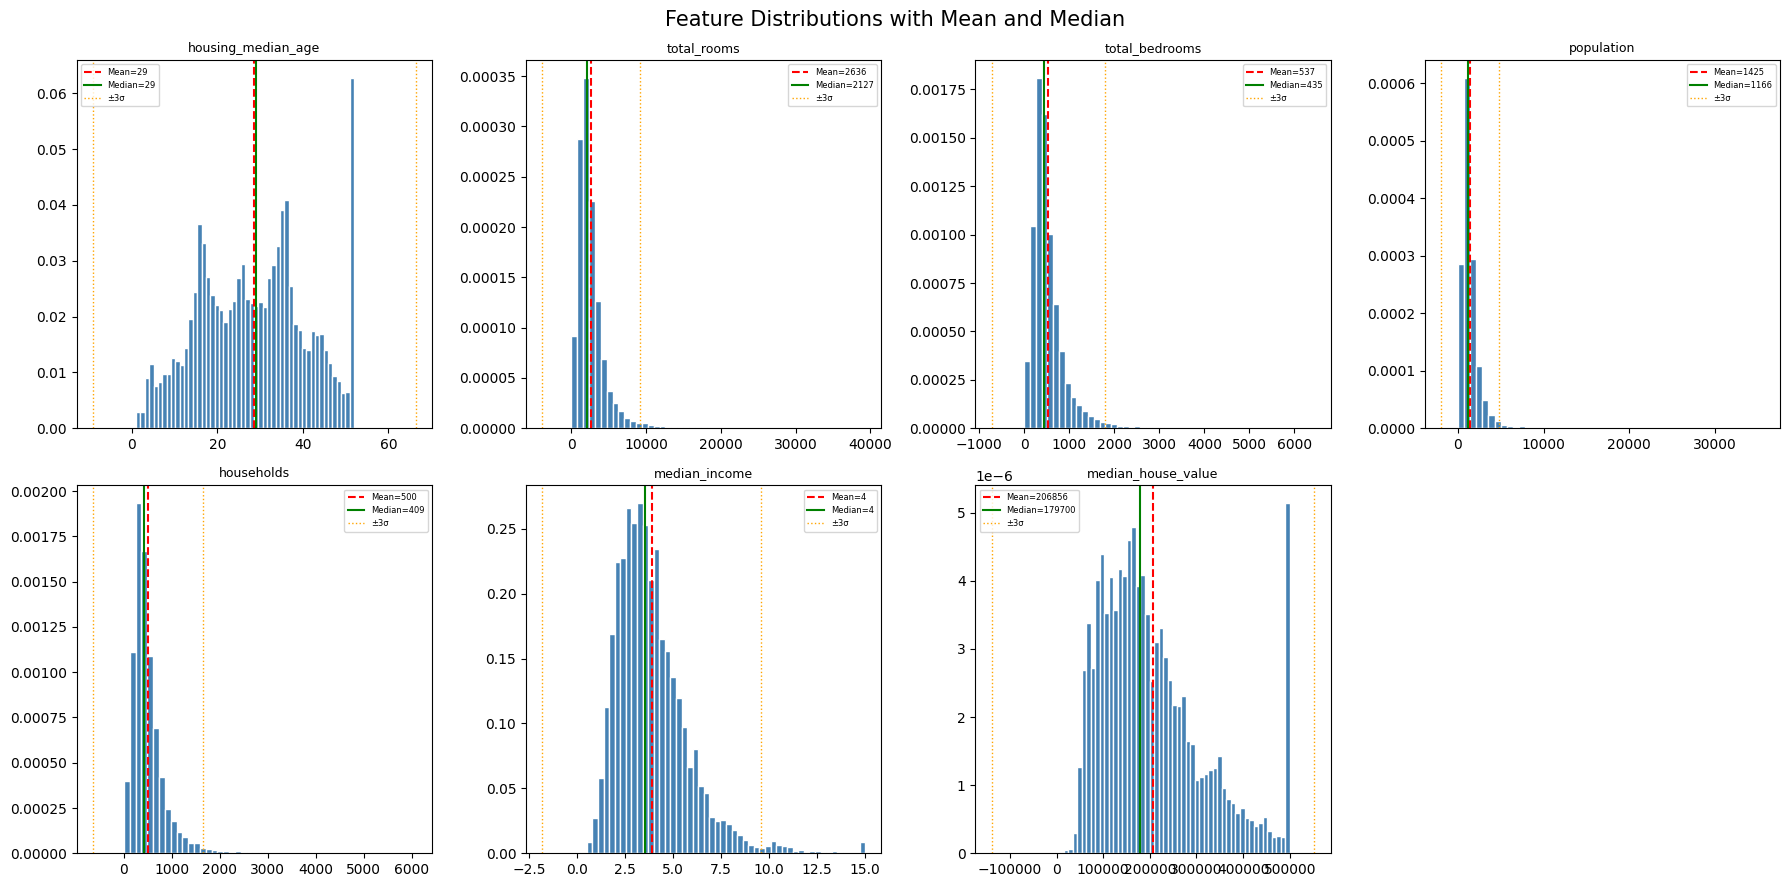

In [10]:
numeric_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
                'population', 'households', 'median_income', 'median_house_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature Distributions with Mean and Median', fontsize=15)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', density=True)
    axes[i].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean:.0f}')
    axes[i].axvline(median, color='green', linestyle='-', linewidth=1.5, label=f'Median={median:.0f}')
    axes[i].axvline(mean - 3*std, color='orange', linestyle=':', linewidth=1, label='±3σ')
    axes[i].axvline(mean + 3*std, color='orange', linestyle=':', linewidth=1)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=6)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("../data/figures/eda/skewness_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

## EDA - Correlation Analysis
Correlation matrix heatmap showing pairwise relationships between features.
median_income has the strongest correlation with the target variable (r=0.69).

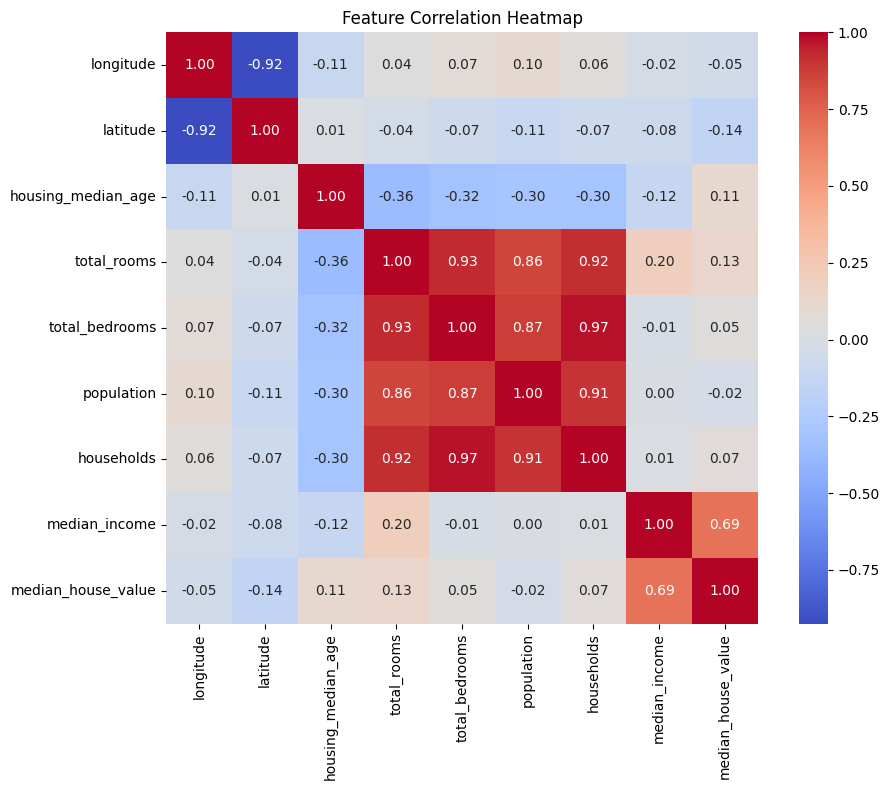

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, square=True)

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig("../data/figures/eda/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## EDA - Outlier Detection (IQR Method)
Box plots using IQR method: outliers fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
Red dots represent the outliers for each feature.

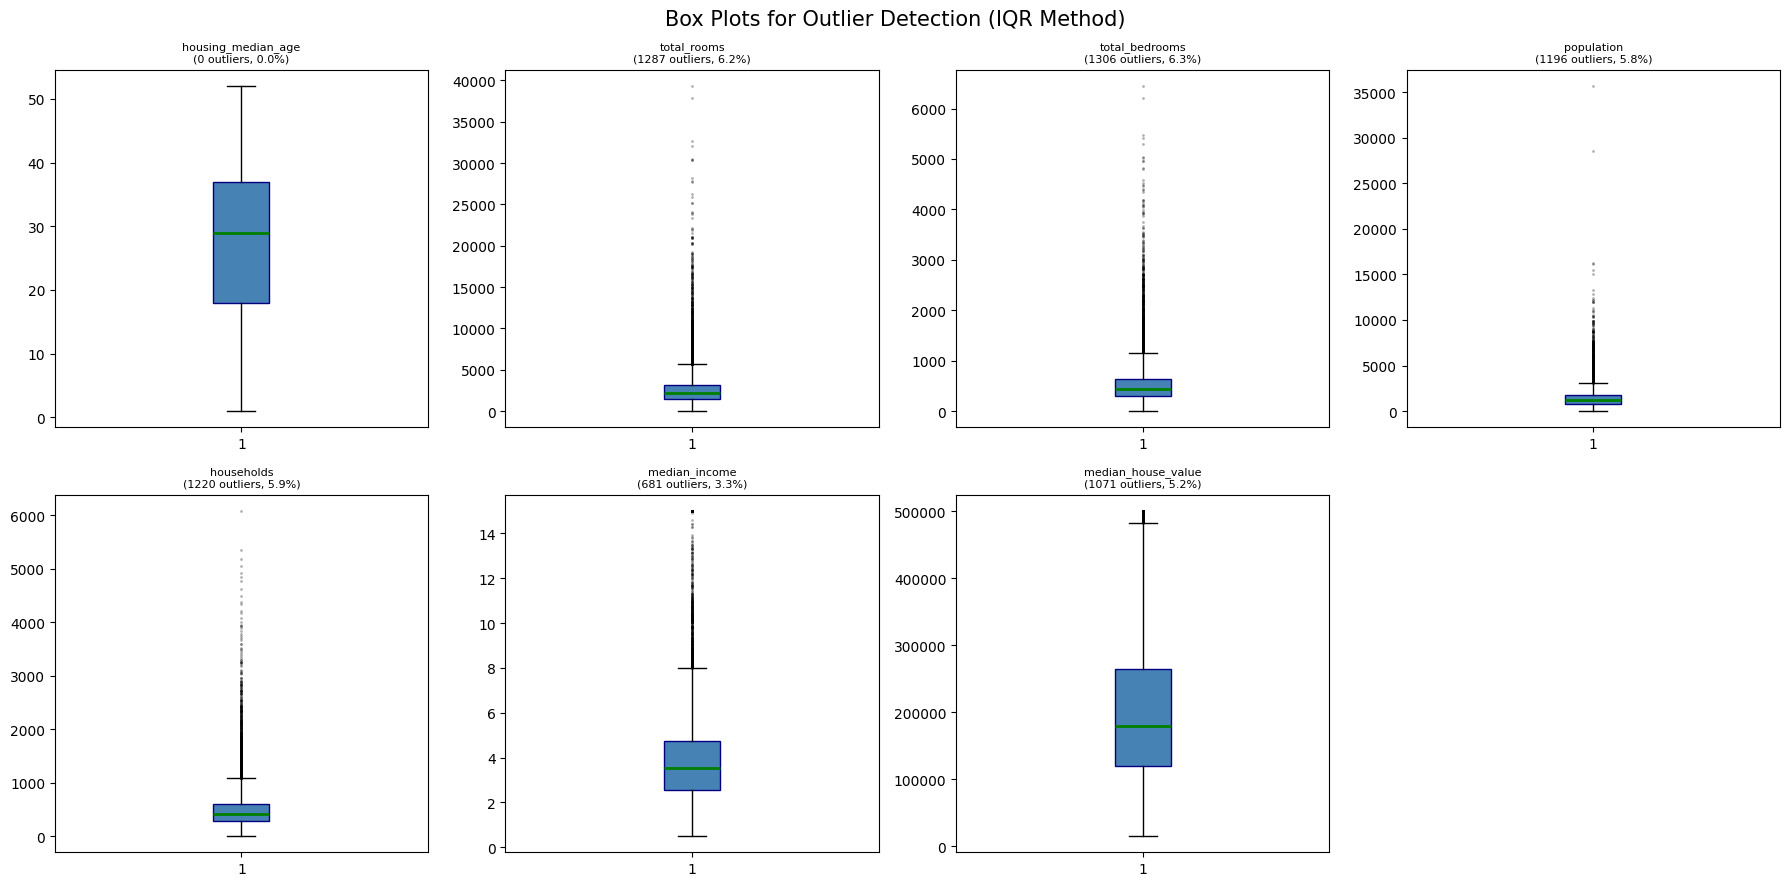

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Box Plots for Outlier Detection (IQR Method)', fontsize=15)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='green', linewidth=2),
                    flierprops=dict(marker='.', color='red', markersize=2, alpha=0.3))
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    axes[i].set_title(f'{col}\n({n_out} outliers, {n_out/len(df)*100:.1f}%)', fontsize=8)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("../data/figures/eda/iqr_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

## EDA - Feature-Target Relationships and Geographic Distribution

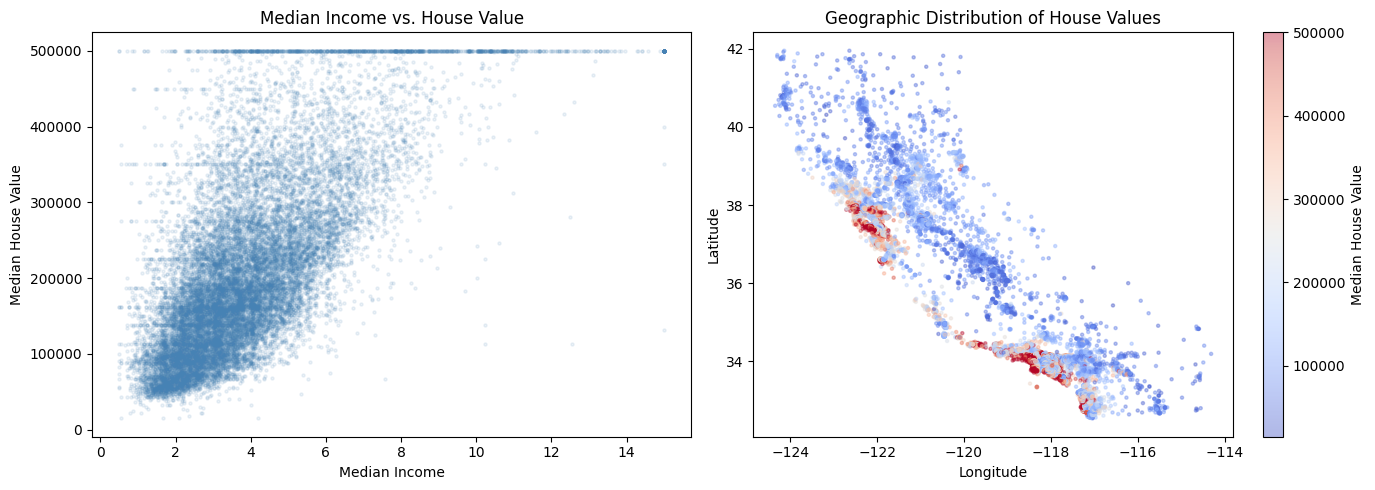

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['median_income'], df['median_house_value'], alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value')
axes[0].set_title('Median Income vs. House Value')

sc = axes[1].scatter(df['longitude'], df['latitude'],
                     c=df['median_house_value'], cmap='coolwarm', alpha=0.4, s=5)
plt.colorbar(sc, ax=axes[1], label='Median House Value')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Geographic Distribution of House Values')

plt.tight_layout()
plt.savefig("../data/figures/eda/scatter_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## EDA - House Value by Ocean Proximity Category

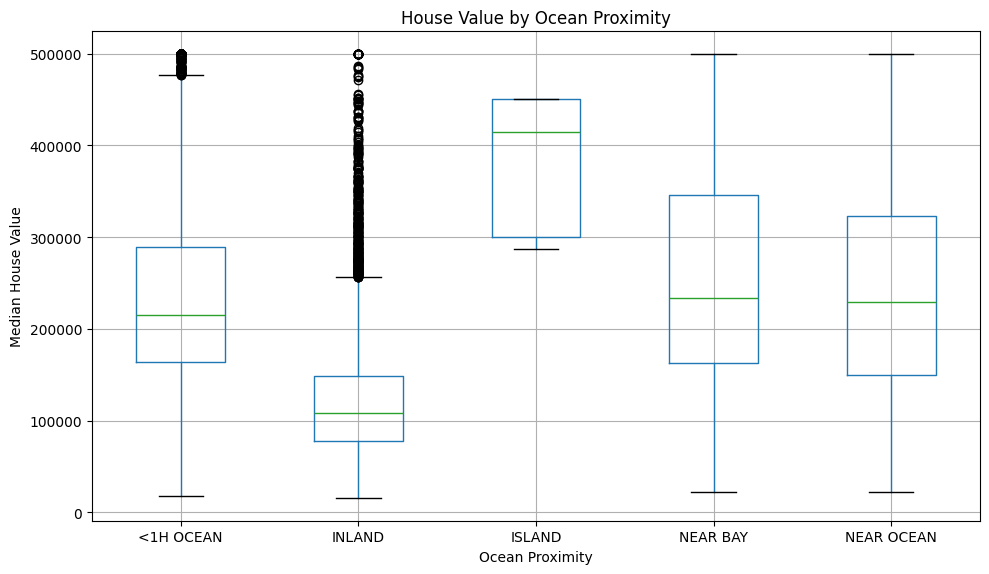

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='median_house_value', by='ocean_proximity', ax=ax)
ax.set_title('House Value by Ocean Proximity')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value')
plt.suptitle('')
plt.tight_layout()
plt.savefig("../data/figures/eda/ocean_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()